In [1]:
from sklearn.impute import SimpleImputer
import pandas as pd
from IPython.display import display
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
def summarize(df: pd.DataFrame, name: str):
    print(f"=== {name} ===")
    print("Shape:", df.shape)
    print("Columns:", list(df.columns))
    print("\nDtypes:\n" + df.dtypes.to_string())
    nulls = df.isna().sum()
    if nulls.any():
        print("\nMissing values (non-zero):")
        print(nulls[nulls > 0].sort_values(ascending=False).to_string())
    else:
        print("\nMissing values: none")

    try:
        mem = df.memory_usage(deep=True).sum()
        print(f"\nApprox. memory usage: {mem/1024/1024:.2f} MB")
    except Exception:
        pass
    print("\nPreview:")
    display(df.head(5))
    print("\n" + "-" * 80)

In [3]:
# Load CSVs and show structure
base = "/Users/kazimostafashahriar/Main Drive/thesis/Medical data analysis/Code"
path_diabetic = f"{base}/diabetic_data.csv"
path_ids = f"{base}/IDS_mapping.csv"

# Read

df = pd.read_csv(path_diabetic, na_values=["?"])
ids_df = pd.read_csv(path_ids, na_values=["?"])



/var/folders/zf/pdy3c0hs5zl3f4wx2fjycvsm0000gn/T/ipykernel_42610/3125645934.py:8: DtypeWarning: Columns (10) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(path_diabetic, na_values=["?"])


In [14]:
df["discharge_disposition_id"].value_counts()

discharge_disposition_id
1     60234
3     13954
6     12902
18     3691
2      2128
22     1993
11     1642
5      1184
25      989
4       815
7       623
23      412
13      399
14      372
28      139
8       108
15       63
24       48
9        21
17       14
16       11
19        8
10        6
27        5
12        3
20        2
Name: count, dtype: int64

In [4]:
summarize(df, "Diabetic Data")


=== Diabetic Data ===
Shape: (101766, 50)
Columns: ['encounter_id', 'patient_nbr', 'race', 'gender', 'age', 'weight', 'admission_type_id', 'discharge_disposition_id', 'admission_source_id', 'time_in_hospital', 'payer_code', 'medical_specialty', 'num_lab_procedures', 'num_procedures', 'num_medications', 'number_outpatient', 'number_emergency', 'number_inpatient', 'diag_1', 'diag_2', 'diag_3', 'number_diagnoses', 'max_glu_serum', 'A1Cresult', 'metformin', 'repaglinide', 'nateglinide', 'chlorpropamide', 'glimepiride', 'acetohexamide', 'glipizide', 'glyburide', 'tolbutamide', 'pioglitazone', 'rosiglitazone', 'acarbose', 'miglitol', 'troglitazone', 'tolazamide', 'examide', 'citoglipton', 'insulin', 'glyburide-metformin', 'glipizide-metformin', 'glimepiride-pioglitazone', 'metformin-rosiglitazone', 'metformin-pioglitazone', 'change', 'diabetesMed', 'readmitted']

Dtypes:
encounter_id                 int64
patient_nbr                  int64
race                        object
gender           

,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),NaN,6,25,1,1,...,No,No,No,No,No,No,No,No,No,NO
1,149190,55629189,Caucasian,Female,[10-20),NaN,1,1,7,3,...,No,Up,No,No,No,No,No,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),NaN,1,1,7,2,...,No,No,No,No,No,No,No,No,Yes,NO
3,500364,82442376,Caucasian,Male,[30-40),NaN,1,1,7,2,...,No,Up,No,No,No,No,No,Ch,Yes,NO
4,16680,42519267,Caucasian,Male,[40-50),NaN,1,1,7,1,...,No,Steady,No,No,No,No,No,Ch,Yes,NO



--------------------------------------------------------------------------------


In [15]:
medications = ['metformin', 'repaglinide', 'nateglinide', 'chlorpropamide', 'glimepiride',
    'acetohexamide', 'glipizide', 'glyburide', 'tolbutamide', 'pioglitazone',
    'rosiglitazone', 'acarbose', 'miglitol', 'troglitazone', 'tolazamide',
    'examide', 'citoglipton', 'insulin', 'glyburide-metformin', 'glipizide-metformin',
    'glimepiride-pioglitazone', 'metformin-rosiglitazone', 'metformin-pioglitazone']

print(f"There are {len(medications)} medications represented as columns in the dataset.")


There are 23 medications represented as columns in the dataset.


In [18]:
df[medications].sample(10)

,metformin,repaglinide,nateglinide,chlorpropamide,glimepiride,acetohexamide,glipizide,glyburide,tolbutamide,pioglitazone,rosiglitazone,acarbose,miglitol,troglitazone,tolazamide,examide,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone
6795,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Steady,No,No,No,No,No
39996,No,No,No,No,No,No,No,No,No,Steady,No,No,No,No,No,No,No,No,No,No,No,No,No
5461,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Steady,No,No,No,No,No
10171,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Down,No,No,No,No,No
32137,No,No,No,No,No,No,Steady,No,No,Steady,No,No,No,No,No,No,No,No,No,No,No,No,No
94962,Steady,No,No,No,No,No,No,No,No,Steady,No,No,No,No,No,No,No,Steady,No,No,No,No,No
873,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No
88632,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No
35292,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Steady,No,No,No,No,No
18532,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No


In [22]:
# ...existing code...
def summarize_medication_status(row):
    # Get all values in the medication columns for this row
    values = row.values
    
    # Filter out 'No' to see what remains
    active_values = [v for v in values if v != 'No']
    
    # Logic based on what remains
    if len(active_values) == 0:
        return "No"
    
    # Get unique active statuses (e.g., checks if they are all "Steady" or mixed "Steady" and "Up")
    unique_active = set(active_values)
    
    if len(unique_active) == 1:
        return list(unique_active)[0] # Returns 'Steady', 'Up', or 'Down'
    else:
        return "Mixed" # Patient has different statuses for different drugs (e.g., one Up, one Steady)

# Apply the function row by row
df['med_summary_status'] = df[medications].apply(summarize_medication_status, axis=1)

df['med_summary_status'].value_counts()

# Count how many active meds (non-"No") per row
df['active_meds_count'] = (df[medications] != 'No').sum(axis=1)

print("Summary of Medication Status per Patient:")
print(df['med_summary_status'].value_counts())

print("\nNumber of patients taking multiple drugs (Mixed status):")
print(df[df['med_summary_status'] == 'Mixed'].shape[0])

Summary of Medication Status per Patient:
med_summary_status
Steady    50660
No        23403
Mixed     11351
Down       8376
Up         7976
Name: count, dtype: int64

Number of patients taking multiple drugs (Mixed status):
11351


In [23]:
#show me medication columns where df['med_summary_status']='mixed'
df[df['med_summary_status'] == 'Mixed'][medications].head(10)

,metformin,repaglinide,nateglinide,chlorpropamide,glimepiride,acetohexamide,glipizide,glyburide,tolbutamide,pioglitazone,rosiglitazone,acarbose,miglitol,troglitazone,tolazamide,examide,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone
11,No,No,No,No,No,No,No,Up,No,No,No,No,No,No,No,No,No,Steady,No,No,No,No,No
12,Steady,Up,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Down,No,No,No,No,No
19,No,No,No,No,No,No,No,Down,No,No,No,No,No,No,No,No,No,Steady,No,No,No,No,No
30,No,No,No,No,No,No,No,Up,No,No,No,Steady,No,No,No,No,No,Steady,No,No,No,No,No
35,No,No,No,No,No,No,No,No,No,No,Steady,No,No,No,No,No,No,Down,No,No,No,No,No
40,Steady,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Down,No,No,No,No,No
46,No,No,No,No,No,No,No,Steady,No,No,No,No,No,No,No,No,No,Down,No,No,No,No,No
47,Up,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Steady,No,No,No,No,No
61,No,No,No,No,No,No,No,No,No,No,No,No,No,Steady,No,No,No,Down,No,No,No,No,No
73,Steady,No,No,No,No,No,Steady,No,No,No,No,No,No,No,No,No,No,Down,No,No,No,No,No


In [ ]:
#give me a null count of each column in df
p
df.isnull().sum()
#give me a percentage of null values of total dataframe



encounter_id                    0
patient_nbr                     0
race                         2273
gender                          0
age                             0
weight                      98569
admission_type_id               0
discharge_disposition_id        0
admission_source_id             0
time_in_hospital                0
payer_code                  40256
medical_specialty           49949
num_lab_procedures              0
num_procedures                  0
num_medications                 0
number_outpatient               0
number_emergency                0
number_inpatient                0
diag_1                         21
diag_2                        358
diag_3                       1423
number_diagnoses                0
max_glu_serum               96420
A1Cresult                   84748
metformin                       0
repaglinide                     0
nateglinide                     0
chlorpropamide                  0
glimepiride                     0
acetohexamide 

In [6]:
# Paste-ready CSV for first 5 rows of diabetic_df (with headers, all columns)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 0)

In [5]:
def impute_data(data):
    '''Returns data with missing values imputed.'''

    # get all categorical columns
    cat_cols = data.select_dtypes(include=['object']).columns

    # get all numerical columns
    num_cols = data.select_dtypes(include=['int64', 'float64']).columns

    # get a copy of the data
    data_copy = data.copy()

    # impute missing values
    imputer = SimpleImputer(strategy='most_frequent')
    imputed_cat_data = imputer.fit_transform(data[cat_cols])
    data_copy.loc[:, cat_cols] = imputed_cat_data

    # impute missing values
    imputer = SimpleImputer(strategy='mean')
    imputed_num_data = imputer.fit_transform(data[num_cols])
    data_copy.loc[:, num_cols] = imputed_num_data

    # return data
    return data_copy

In [ ]:
def add_dtypes(data):
    '''Returns data with dtypes correctly assigned.'''

    numeric_cols = ['time_in_hospital', 'num_lab_procedures', 'num_procedures', 'num_medications', 'number_outpatient', 'number_emergency', 'number_inpatient', 'number_diagnoses']
    categorical = data.columns.difference(numeric_cols)

    # assign dtypes to float to numeric columns
    data[numeric_cols] = data[numeric_cols].astype('float')

    # assign dtypes to object to categorical columns
    data[categorical] = data[categorical].astype('object')

    # return data
    return data

In [10]:
#correlation matrix on the selected columns
df_corr = df.corr()

#colum

ValueError: could not convert string to float: 'Caucasian'

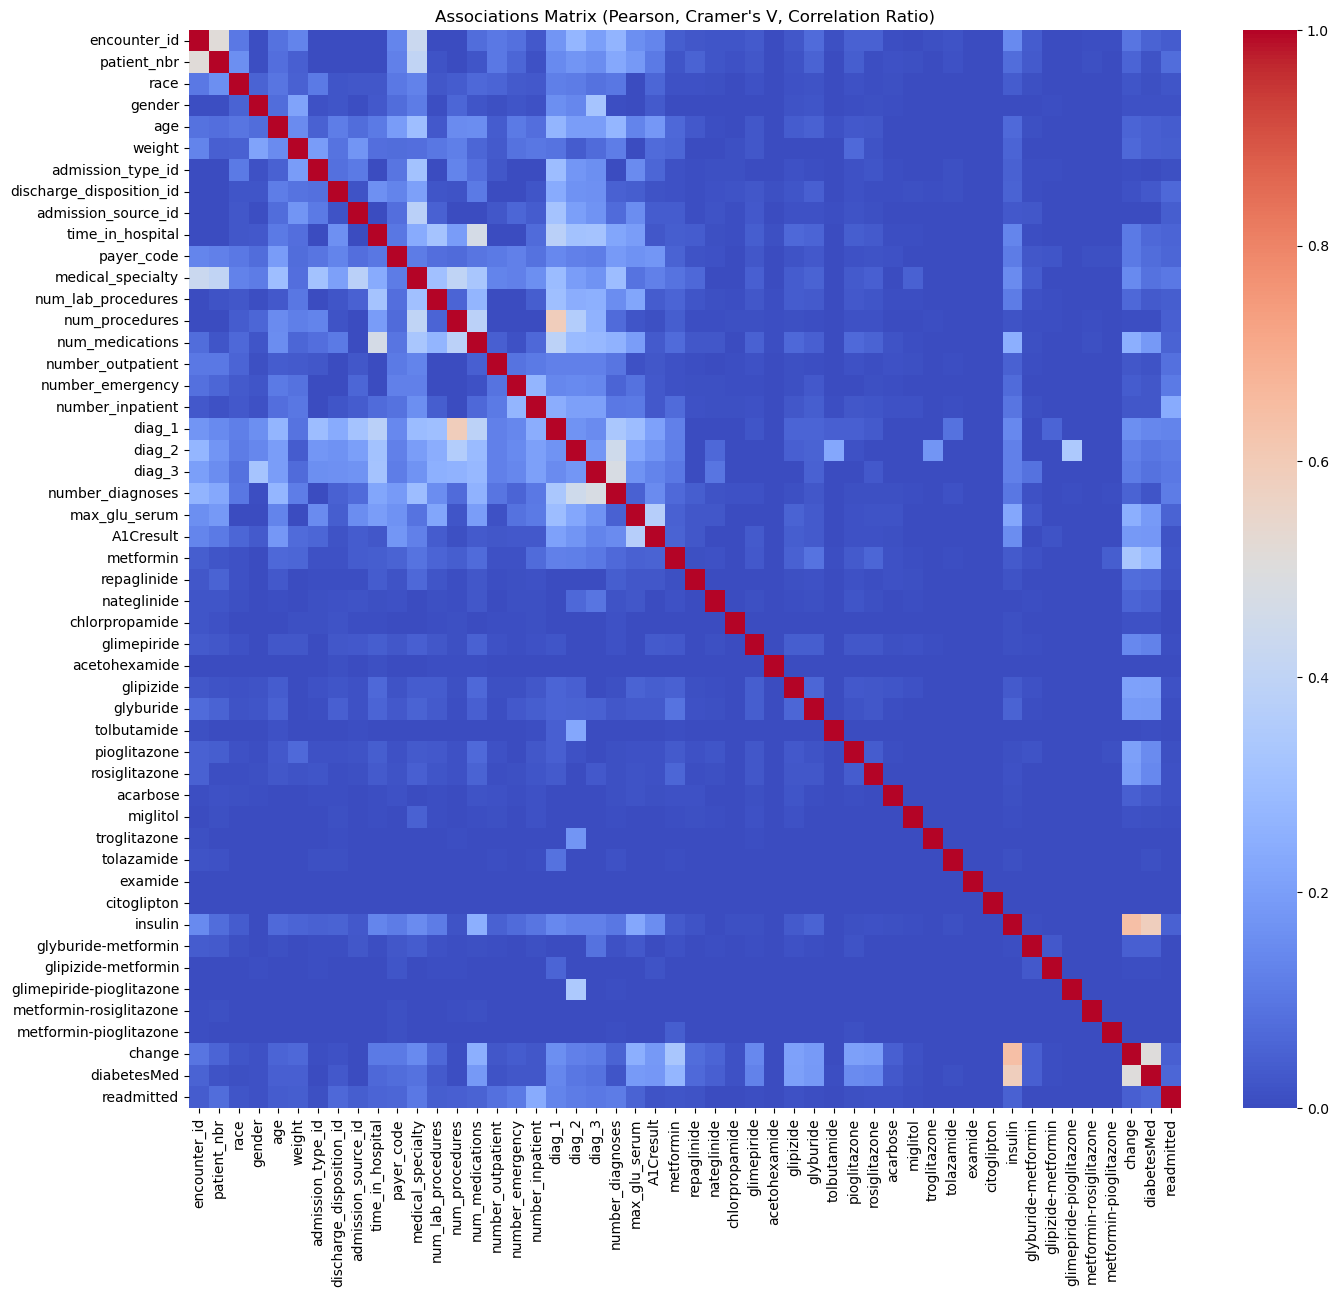

In [11]:
# ...existing code...
#correlation matrix on the selected columns
# df_corr = df.corr()

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import scipy.stats as ss

def cramers_v(x, y):
    confusion_matrix = pd.crosstab(x, y)
    if confusion_matrix.size == 0: return 0.0
    chi2 = ss.chi2_contingency(confusion_matrix)[0]
    n = confusion_matrix.sum().sum()
    phi2 = chi2 / n
    r, k = confusion_matrix.shape
    phi2corr = max(0, phi2 - ((k-1)*(r-1))/(n-1))
    rcorr = r - ((r-1)**2)/(n-1)
    kcorr = k - ((k-1)**2)/(n-1)
    if min((kcorr-1), (rcorr-1)) <= 0: return 0.0
    return np.sqrt(phi2corr / min((kcorr-1), (rcorr-1)))

def correlation_ratio(categories, measurements):
    # Measures how much variance in the number is explained by the category
    cat, _ = pd.factorize(categories)
    measurements = np.asanyarray(measurements)
    
    # Drop NaNs for calculation
    mask = ~pd.isnull(categories) & ~pd.isnull(measurements)
    cat = cat[mask]
    measurements = measurements[mask]
    
    if len(measurements) == 0: return 0.0

    y_var = np.var(measurements)
    if y_var == 0: return 0.0
    
    unique_cats = np.unique(cat)
    numerator = 0
    total_mean = np.mean(measurements)
    
    for i in unique_cats:
        indices = (cat == i)
        n_c = np.sum(indices)
        if n_c > 0:
            mean_c = np.mean(measurements[indices])
            numerator += n_c * (mean_c - total_mean)**2
        
    eta = np.sqrt(numerator / (len(measurements) * y_var))
    return eta

# Setup matrix
# Selecting fewer columns for speed if dataset is huge, otherwise use df.columns
cols = df.columns 
corr_matrix = pd.DataFrame(index=cols, columns=cols, dtype=float)

for i in cols:
    for j in cols:
        if i == j:
            corr_matrix.loc[i, j] = 1.0
            continue
        
        # Check types
        is_i_num = pd.api.types.is_numeric_dtype(df[i])
        is_j_num = pd.api.types.is_numeric_dtype(df[j])
        
        if is_i_num and is_j_num:
            # Num-Num: Pearson
            corr_matrix.loc[i, j] = df[i].corr(df[j])
        elif not is_i_num and not is_j_num:
            # Cat-Cat: Cramer's V
            corr_matrix.loc[i, j] = cramers_v(df[i], df[j])
        else:
            # Cat-Num: Correlation Ratio
            if not is_i_num:
                corr_matrix.loc[i, j] = correlation_ratio(df[i], df[j])
            else:
                corr_matrix.loc[i, j] = correlation_ratio(df[j], df[i])

# Plotting
plt.figure(figsize=(16, 14))
sns.heatmap(corr_matrix, annot=False, cmap='coolwarm', vmin=0, vmax=1)
plt.title("Associations Matrix (Pearson, Cramer's V, Correlation Ratio)")
plt.show()